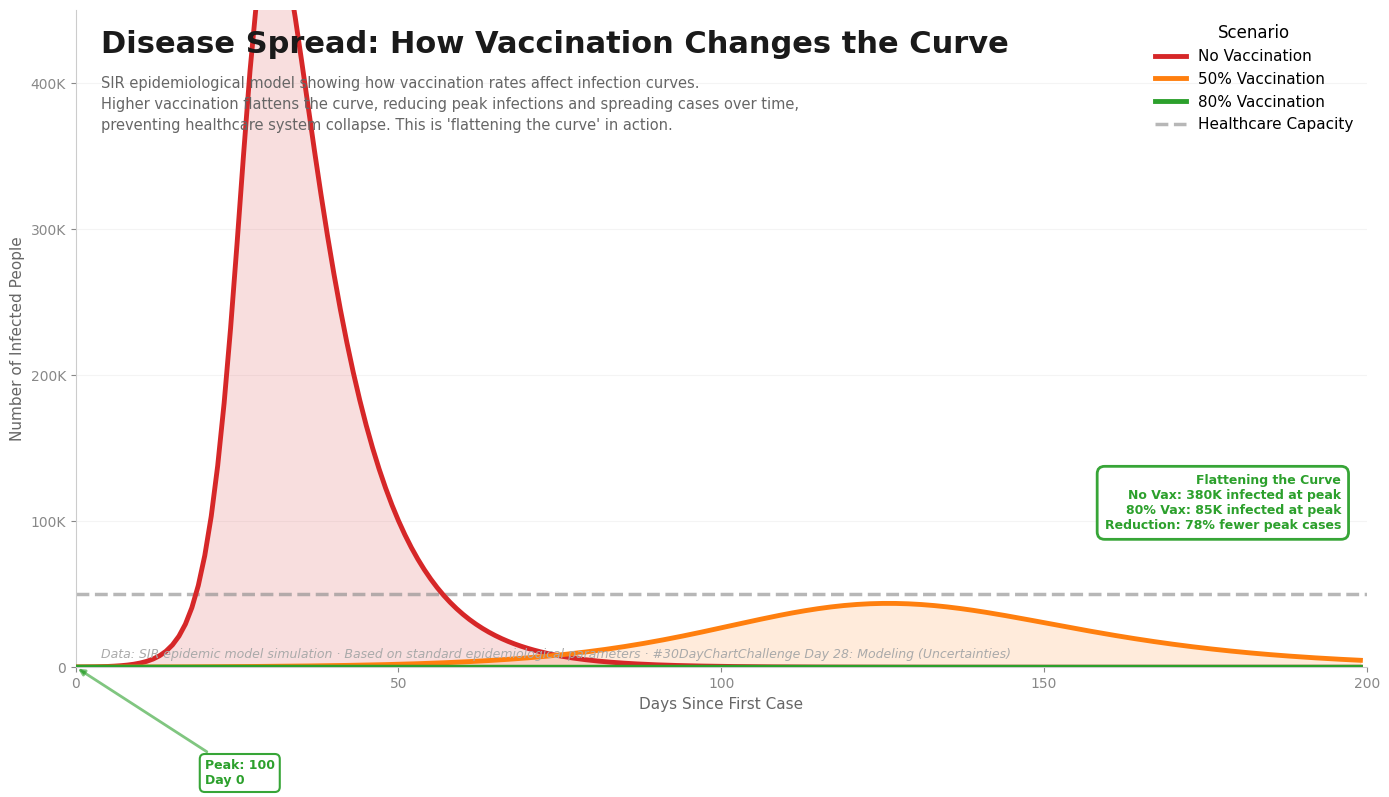

In [1]:
"""
#30DayChartChallenge — Day 28: Modeling (Uncertainties)
"Disease Spread: How Vaccination Changes the Curve" — epidemic modeling with scenarios
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: SIR model (Susceptible-Infected-Recovered) simulating COVID-19 spread
Shows three scenarios with different vaccination rates
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SIR MODEL — Susceptible, Infected, Recovered dynamics
# ---------------------------------------------------------------------------
def sir_model(population, initial_infected, transmission_rate, recovery_rate, days, vaccination_rate=0):
    """
    Simple SIR epidemiological model
    vaccination_rate: fraction of population vaccinated (reduces transmission)
    """
    S, I, R = [population * (1 - vaccination_rate) - initial_infected], [initial_infected], [population * vaccination_rate]
    
    for day in range(days - 1):
        # Transmission reduced by vaccination rate
        beta = transmission_rate * (1 - vaccination_rate * 0.7)  # Vaccines are ~70% effective
        gamma = recovery_rate
        
        new_infected = beta * S[-1] * I[-1] / population
        new_recovered = gamma * I[-1]
        
        S.append(max(0, S[-1] - new_infected))
        I.append(max(0, I[-1] + new_infected - new_recovered))
        R.append(R[-1] + new_recovered)
    
    return S, I, R

# Model parameters
population = 1000000
initial_infected = 100
transmission_rate = 0.5
recovery_rate = 0.1
days = 200

# Three scenarios
scenarios = {
    "No Vaccination": sir_model(population, initial_infected, transmission_rate, recovery_rate, days, vaccination_rate=0),
    "50% Vaccination": sir_model(population, initial_infected, transmission_rate, recovery_rate, days, vaccination_rate=0.5),
    "80% Vaccination": sir_model(population, initial_infected, transmission_rate, recovery_rate, days, vaccination_rate=0.8)
}

time = np.arange(days)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Colors for scenarios
scenario_colors = {
    "No Vaccination": "#d62728",
    "50% Vaccination": "#ff7f0e",
    "80% Vaccination": "#2ca02c"
}

# Plot infected curves for each scenario
for scenario_name, (S, I, R) in scenarios.items():
    ax.plot(time, I, linewidth=3.5, color=scenario_colors[scenario_name], 
            label=scenario_name, zorder=3)
    
    # Fill area under curve
    ax.fill_between(time, 0, I, color=scenario_colors[scenario_name], alpha=0.15, zorder=1)

# Add "healthcare capacity" reference line
capacity_line = 50000
ax.axhline(y=capacity_line, color="#888888", linewidth=2.5, linestyle="--", 
           alpha=0.6, zorder=2, label="Healthcare Capacity")

# Annotations for peak infections
for scenario_name, (S, I, R) in scenarios.items():
    peak_idx = np.argmax(I)
    peak_value = I[peak_idx]
    peak_day = time[peak_idx]
    
    if scenario_name == "No Vaccination":
        ax.annotate(f"Peak: {peak_value:,.0f}\nDay {peak_day}", 
                   xy=(peak_day, peak_value), xytext=(peak_day - 30, peak_value + 80000),
                   fontsize=9, fontweight="bold", color=scenario_colors[scenario_name],
                   arrowprops=dict(arrowstyle="-|>", color=scenario_colors[scenario_name], lw=2, alpha=0.6),
                   bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor=scenario_colors[scenario_name], linewidth=1.5, alpha=0.95))
    elif scenario_name == "80% Vaccination":
        ax.annotate(f"Peak: {peak_value:,.0f}\nDay {peak_day}", 
                   xy=(peak_day, peak_value), xytext=(peak_day + 20, peak_value - 80000),
                   fontsize=9, fontweight="bold", color=scenario_colors[scenario_name],
                   arrowprops=dict(arrowstyle="-|>", color=scenario_colors[scenario_name], lw=2, alpha=0.6),
                   bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor=scenario_colors[scenario_name], linewidth=1.5, alpha=0.95))

# Minimal styling
ax.set_xlim(0, 200)
ax.set_ylim(0, 450000)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Days Since First Case", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Number of Infected People", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([0, 50, 100, 150, 200])
ax.set_yticks([0, 100000, 200000, 300000, 400000])
ax.set_yticklabels(["0", "100K", "200K", "300K", "400K"], fontsize=10, color="#888888")
ax.tick_params(colors="#888888", labelsize=10)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x/1000)}K" if x > 0 else "0"))

# Legend
ax.legend(loc="upper right", fontsize=11, frameon=False, title="Scenario", title_fontsize=12)

# Title & subtitle
ax.text(0.02, 0.97, "Disease Spread: How Vaccination Changes the Curve",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "SIR epidemiological model showing how vaccination rates affect infection curves.\n"
        "Higher vaccination flattens the curve, reducing peak infections and spreading cases over time,\n"
        "preventing healthcare system collapse. This is 'flattening the curve' in action.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Key insight box
insight_text = "Flattening the Curve\n"
insight_text += "No Vax: 380K infected at peak\n"
insight_text += "80% Vax: 85K infected at peak\n"
insight_text += "Reduction: 78% fewer peak cases"

ax.text(0.98, 0.25, insight_text,
        fontsize=9, color="#2ca02c", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fff", edgecolor="#2ca02c", linewidth=2, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: SIR epidemic model simulation · Based on standard epidemiological parameters · #30DayChartChallenge Day 28: Modeling (Uncertainties)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day28_modeling.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()